# <a id='toc1_'></a>[PyTorch](https://pytorch.org/)  [&#8593;](#toc0_)

![](Pics/torch001.png)

[PyTorch Tutorials](https://pytorch.org/tutorials/)




**Table of contents**<a id='toc0_'></a>    
- [PyTorch ](#toc1_)    
- [Learn the Basics](#toc2_)    
  - [0. Quickstart](#toc2_1_)    
    - [Working with data](#toc2_1_1_)    
    - [Creating Models](#toc2_1_2_)    
    - [Optimizing the Model Parameters](#toc2_1_3_)    
    - [Saving & Loading Models](#toc2_1_4_)    
  - [1. Tensors](#toc2_2_)    
    - [Tensor Initialization](#toc2_2_1_)    
    - [Tensor Attributes](#toc2_2_2_)    
    - [Tensor Operations](#toc2_2_3_)    
    - [Bridge with NumPy](#toc2_2_4_)    
  - [2. Datasets and DataLoaders](#toc2_3_)    
      - [Loading a Dataset](#toc2_3_1_1_)    
      - [Iterating and Visualizing the Dataset](#toc2_3_1_2_)    
      - [Creating a Custom Dataset for your files](#toc2_3_1_3_)    
      - [Preparing your data for training with DataLoaders](#toc2_3_1_4_)    
      - [Iterate through the DataLoader](#toc2_3_1_5_)    
  - [3. Transforms](#toc2_4_)    
  - [4. Build Model](#toc2_5_)    
  - [5. Automatic Differentiation](#toc2_6_)    
  - [6. Optimization Loop](#toc2_7_)    
  - [7. Save, Load and Use Model](#toc2_8_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Learn the Basics](#toc0_)

[Learn the Basics](https://pytorch.org/tutorials/beginner/basics/intro.html)


## <a id='toc2_1_'></a>[0. Quickstart](#toc0_)


### <a id='toc2_1_1_'></a>[Working with data](#toc0_)

PyTorch has two primitives to work with data:
1. torch.utils.data.**DataLoader**  - DataLoader wraps an iterable around the Dataset
2. torch.utils.data.**Dataset**     - Dataset stores the samples and their corresponding labels


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor


/home/lzy/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/lzy/.local/lib/python3.10/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


PyTorch offers domain-specific libraries - (all of which include datasets)
1. TorchText
2. TorchVision
3. TorchAudio

The torchvision.datasets module contains Dataset objects for many real-world vision data like CIFAR, COCO

Full List [torchvision.datasets](https://pytorch.org/vision/stable/datasets.html)

Every TorchVision Dataset includes two arguments to modify the samples and labels respectively
1. transform - 用于对样本进行变换
   1. 可以包含多种不同的操作，如缩放、裁剪、归一化等
   2. 目的是通过这些预处理步骤来增强模型的泛化能力或使模型训练更为高效
   3. 可以使用transforms.Compose来组合多个图像变换操作
2. target_transform - 用于对标签进行变换
   1. 如进行编码或转换成某种特定的格式

In [2]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="/home/lzy/Datasets",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="/home/lzy/Datasets",
    train=False,
    download=True,
    transform=ToTensor(),
)


We pass the **Dataset** as an argument to **DataLoader**. 

This wraps an iterable over our dataset, and supports automatic batching, sampling, shuffling and multiprocess data loading. 

Here we define a batch size of 64, i.e. each element in the dataloader iterable will return a batch of 64 features and labels.

In [3]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break


Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


### <a id='toc2_1_2_'></a>[Creating Models](#toc0_)

To define a neural network in PyTorch, we **create a class that inherits from nn.Module**
1. define the layers of the network in the **\_\_init\_\_ function**
2. specify how data will pass through the network in the **forward function**

To accelerate operations in the neural network, we move it to the GPU or MPS if available.

In [4]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")


Using cpu device


/home/lzy/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:141: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [5]:
# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()  # 确保父类的构造函数也被正确地调用
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),  # 根据前面的 shape
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


### <a id='toc2_1_3_'></a>[Optimizing the Model Parameters](#toc0_)

To train a model, we need a loss function and an optimizer.

In [6]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)


In a single training loop, the model makes predictions on the training dataset (fed to it in batches)

and backpropagates the prediction error to adjust the model’s parameters

also check the model’s performance against the test dataset to ensure it is learning

In [7]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


In [8]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")


Epoch 1
-------------------------------
loss: 2.290570  [   64/60000]


loss: 2.283890  [ 6464/60000]
loss: 2.263189  [12864/60000]
loss: 2.269283  [19264/60000]
loss: 2.247993  [25664/60000]
loss: 2.212625  [32064/60000]
loss: 2.221527  [38464/60000]
loss: 2.183008  [44864/60000]
loss: 2.181445  [51264/60000]
loss: 2.159443  [57664/60000]
Test Error: 
 Accuracy: 46.9%, Avg loss: 2.148400 

Epoch 2
-------------------------------
loss: 2.149203  [   64/60000]
loss: 2.144089  [ 6464/60000]
loss: 2.085546  [12864/60000]
loss: 2.117700  [19264/60000]
loss: 2.052359  [25664/60000]
loss: 1.983450  [32064/60000]
loss: 2.017752  [38464/60000]
loss: 1.929759  [44864/60000]
loss: 1.943975  [51264/60000]
loss: 1.870910  [57664/60000]
Test Error: 
 Accuracy: 55.4%, Avg loss: 1.869483 

Epoch 3
-------------------------------
loss: 1.897509  [   64/60000]
loss: 1.868994  [ 6464/60000]
loss: 1.749479  [12864/60000]
loss: 1.810547  [19264/60000]
loss: 1.690134  [25664/60000]
loss: 1.631396  [32064/60000]
loss: 1.665096  [38464/60000]
loss: 1.562744  [44864/60000]
loss: 

### <a id='toc2_1_4_'></a>[Saving & Loading Models](#toc0_)

A common way to save a model is to serialize the internal state dictionary (containing the model parameters).

The process for loading a model includes re-creating the model structure and loading the state dictionary into it.

In [ ]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

# print(model.state_dict())


Saved PyTorch Model State to model.pth


In [10]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth"))

print(model)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [12]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
x, y = test_data[0][0], test_data[0][1]

with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')


Predicted: "Ankle boot", Actual: "Ankle boot"


## <a id='toc2_2_'></a>[1. Tensors](#toc0_)


Tensors are a specialized data structure that are very similar to arrays and matrices. 

In PyTorch, we use tensors to encode the inputs and outputs of a model, as well as the model’s parameters.

Tensors are similar to **NumPy’s ndarrays**

except that **tensors can run on GPUs or other hardware accelerators**

In fact, tensors and NumPy arrays **can often share the same underlying memory**, eliminating the need to copy data.

Tensors are also **optimized for automatic differentiation**.


In [31]:
import torch
import numpy as np


### <a id='toc2_2_1_'></a>[Tensor Initialization](#toc0_)

Tensors can be initialized in various ways
1. Directly from data - The **data type is automatically inferred**.
2. From a NumPy array
3. From another tensor
4. With random or constant values:


In [32]:
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)
print(x_data)

np_array = np.array(data)
x_np = torch.from_numpy(np_array)  # 与 np_array 共享空间
# x_np = torch.tensor(np_array)  # 不与 np_array 共享空间
print(x_np)

x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")
x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

shape = (2, 3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)
print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")


tensor([[1, 2],
        [3, 4]])
tensor([[1, 2],
        [3, 4]])
Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.5090, 0.0472],
        [0.3021, 0.5488]]) 

Random Tensor: 
 tensor([[0.2904, 0.1855, 0.9735],
        [0.6025, 0.7251, 0.8648]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


### <a id='toc2_2_2_'></a>[Tensor Attributes](#toc0_)

Tensor attributes describe their
1. shape
2. datatype
3. device on which they are stored.

In [3]:
tensor = torch.rand(3, 4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")
tensor = tensor.to("cuda")
print(f"Device tensor is stored on: {tensor.device}")


Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu
Device tensor is stored on: cuda:0


### <a id='toc2_2_3_'></a>[Tensor Operations](#toc0_)

Over 100 tensor operations, including
1. transposing
2. indexing
3. slicing
4. mathematical operations
5. linear algebra
6. random sampling

Each of them can be run on the GPU (at typically higher speeds than on a CPU)

In [6]:
# We move our tensor to the GPU if available
if torch.cuda.is_available():
    tensor = tensor.to('cuda')
    print(f"Device tensor is stored on: {tensor.device}")

print(torch.is_tensor(tensor))


Device tensor is stored on: cuda:0
True


In [15]:
tensor = torch.ones(4, 4)
tensor[:,1] = 0
print(tensor)


tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [16]:
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)


tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


In [17]:
# This computes the element-wise product
print(f"tensor.mul(tensor) \n {tensor.mul(tensor)} \n")
# Alternative syntax:
print(f"tensor * tensor \n {tensor * tensor}")


tensor.mul(tensor) 
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor * tensor 
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [18]:
print(f"tensor.matmul(tensor.T) \n {tensor.matmul(tensor.T)} \n")
# Alternative syntax:
print(f"tensor @ tensor.T \n {tensor @ tensor.T}")


tensor.matmul(tensor.T) 
 tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]]) 

tensor @ tensor.T 
 tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])


In [19]:
# In-place operations Operations that have a _ suffix are in-place. For example: x.copy_(y), x.t_(), will change x.

print(tensor, "\n")
tensor.add_(5)
print(tensor)


tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])


### <a id='toc2_2_4_'></a>[Bridge with NumPy](#toc0_)

Tensors on the CPU and NumPy arrays can share their underlying memory locations, and changing one will change the other.


In [28]:
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t.add_(1)
print(f"t: {t}")
print(f"n: {n}")


t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]
t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


In [29]:
n = np.ones(5)
t = torch.from_numpy(n)  # 共享空间

np.add(n, 1, out=n)
print(f"t: {t}")
print(f"n: {n}")


t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


In [30]:
n = np.ones(5)
t = torch.tensor(n)  # 不共享空间

np.add(n, 1, out=n)
print(f"t: {t}")
print(f"n: {n}")


t: tensor([1., 1., 1., 1., 1.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


## <a id='toc2_3_'></a>[2. Datasets and DataLoaders](#toc0_)

Code for processing data samples can get messy and hard to maintain;

ideally want our **dataset code to be decoupled from our model training code** for better readability and modularity

PyTorch provides two data primitives that allow you to use pre-loaded datasets as well as your own data.
1. torch.utils.data.DataLoader - DataLoader wraps an iterable around the Dataset to enable easy access to the samples
2. torch.utils.data.Dataset - Dataset stores the samples and their corresponding labels

PyTorch domain libraries provide a number of pre-loaded datasets

subclass torch.utils.data.Dataset and implement functions specific to the particular data

They can be used to prototype and benchmark your model
1. [Image Datasets](https://pytorch.org/vision/stable/datasets.html)
2. [Text Datasets](https://pytorch.org/text/stable/datasets.html)
3. [Audio Datasets](https://pytorch.org/audio/stable/datasets.html)

### <a id='toc2_3_1_1_'></a>[Loading a Dataset](#toc0_)

28×28 grayscale image and an associated label from one of 10 classes.

We load the FashionMNIST Dataset with the following parameters:
1. **root**             is the path where the train/test data is stored
2. **train**            specifies training or test dataset
3. **download=True**    downloads the data from the internet if it’s not available at root
4. **transform**        and **target_transform** specify the feature and label transformations

In [3]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="/home/lzy/Datasets",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="/home/lzy/Datasets",
    train=False,
    download=True,
    transform=ToTensor()
)




In [4]:
print(type(training_data[0]))  # 一个Tensor + 一个label
print([type(i) for i in training_data[0]])
print(torch.is_tensor(training_data[0][0]))  # True


<class 'tuple'>
[<class 'torch.Tensor'>, <class 'int'>]
True


### <a id='toc2_3_1_2_'></a>[Iterating and Visualizing the Dataset](#toc0_)

We can index Datasets manually like a list: training_data[index].

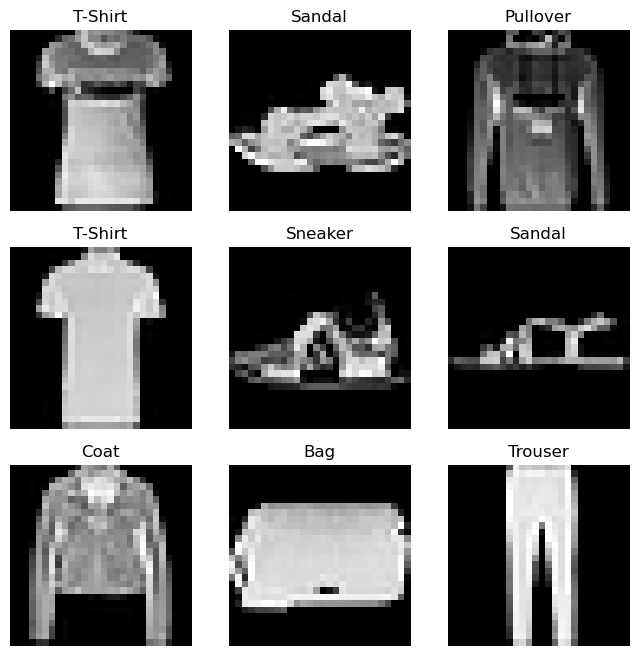

In [5]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3  # 定义图形中的子图排列方式
for i in range(1, cols * rows + 1):  # 确保了总共会处理9个元素
    sample_idx = torch.randint(len(training_data), size=(1,)).item()  # .item() 方法用于从只包含单个值的tensor中提取这个值并将其转换为一个Python数值
    img, label = training_data[sample_idx]  # 通过随机索引从训练数据集中获取图像和其对应的标签
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
    # squeeze() 方法用于去除数组中维度为1的轴
    # cmap 参数代表“colormap”，这个参数决定了如何将数据的数值映射到颜色上。"gray" 表示使用灰度颜色映射，这意味着图像将以灰阶（从黑到白）显示，而不是彩色。
plt.show()


### <a id='toc2_3_1_3_'></a>[Creating a Custom Dataset for your files](#toc0_)

A custom Dataset class must implement three functions:
1. \_\_init\_\_
   1. run once when instantiating the Dataset object
   2. initialize the directory containing the images, the annotations file, and both transforms
2. \_\_len\_\_
   1. returns the number of samples in our dataset
3. \_\_getitem\_\_
   1. loads and returns a sample from the dataset at the given index idx
   2. Based on the index, it identifies the image’s location on disk, converts that to a tensor using read_image
   3. retrieves the corresponding label from the csv data in self.img_labels
   4. calls the transform functions on them (if applicable)
   5. returns the tensor image and corresponding label in a tuple






In [6]:
import os
import pandas as pd
from torch.utils.data import Dataset
from torchvision.io import read_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label


### <a id='toc2_3_1_4_'></a>[Preparing your data for training with DataLoaders](#toc0_)

The Dataset retrieves our dataset’s features and labels one sample at a time. 

While training a model, we typically want to 
1. pass samples in **minibatches**
2. **reshuffle** the data at every epoch to reduce model overfitting
3. use Python’s **multiprocessing** to speed up data retrieval

DataLoader is an iterable that abstracts this complexity for us in an easy API.

In [9]:
from torch.utils.data import DataLoader
from collections.abc import Iterable, Iterator

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True, num_workers=8)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True, num_workers=8)

print(isinstance(train_dataloader, Iterable))  # 只是   iterable
print(isinstance(train_dataloader, Iterator))  # 还不是 iterator



True
False


### <a id='toc2_3_1_5_'></a>[Iterate through the DataLoader](#toc0_)

We have loaded that dataset into the DataLoader and can iterate through the dataset as needed.

Each iteration below returns a batch of train_features and train_labels - containing **batch_size**=64 features and labels 

Because we specified **shuffle**=True, after we iterate over all batches the data is shuffled

for finer-grained control over the data loading order, take a look at Samplers

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


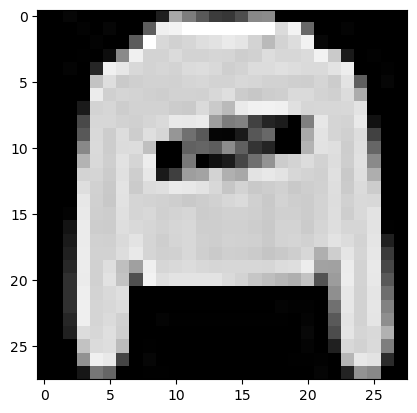

Label: 2


In [30]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")



## <a id='toc2_4_'></a>[3. Transforms](#toc0_)

Data does not always come in its final processed form that is required for training machine learning algorithms

use transforms to perform some manipulation of the data and **make it suitable for training**.

All TorchVision datasets have two parameters that accept callables containing the transformation logic
1. transform to modify the features
2. target_transform to modify the labels

The FashionMNIST features are in PIL Image format, and the labels are integers.

For training, we need the features as normalized tensors, and the labels as one-hot encoded tensors.

To make these transformations, we use **ToTensor** and **Lambda**.
1. **ToTensor** converts a PIL image or NumPy ndarray into a **FloatTensor**. and scales the image’s pixel intensity **values in the range [0., 1.]**
2. **Lambda** transforms apply any **user-defined lambda function**. 

In [32]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

ds = datasets.FashionMNIST(
    root="/home/lzy/Datasets",
    train=True,
    download=True,
    transform=ToTensor(),
    
    # 从一个整数转换为一个长度为10的独热编码（one-hot encoding）向量
    # dim=0 指定了操作的维度。
    # index=torch.tensor(y) 是一个包含标签整数值的张量，这里 y 就是原始的类别标签。因为FashionMNIST的标签是从0到9的整数，所以这个标签直接用作索引。
    # value=1 指定了要填入的值，即在对应的位置上填入1来完成独热编码。
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
    # Here, we define a function to turn the integer into a one-hot encoded tensor.
    # It first creates a zero tensor of size 10 (the number of labels in our dataset) 
    # and calls scatter_ which assigns a value=1 on the index as given by the label y.
)

help(torch.Tensor.scatter_)


Help on method_descriptor:

scatter_(...)
    scatter_(dim, index, src, reduce=None) -> Tensor
    
    Writes all values from the tensor :attr:`src` into :attr:`self` at the indices
    specified in the :attr:`index` tensor. For each value in :attr:`src`, its output
    index is specified by its index in :attr:`src` for ``dimension != dim`` and by
    the corresponding value in :attr:`index` for ``dimension = dim``.
    
    For a 3-D tensor, :attr:`self` is updated as::
    
        self[index[i][j][k]][j][k] = src[i][j][k]  # if dim == 0
        self[i][index[i][j][k]][k] = src[i][j][k]  # if dim == 1
        self[i][j][index[i][j][k]] = src[i][j][k]  # if dim == 2
    
    This is the reverse operation of the manner described in :meth:`~Tensor.gather`.
    
    :attr:`self`, :attr:`index` and :attr:`src` (if it is a Tensor) should all have
    the same number of dimensions. It is also required that
    ``index.size(d) <= src.size(d)`` for all dimensions ``d``, and that
    ``index.

In [52]:
import torch
import numpy as np
np_arr = np.zeros(shape=(3,5), dtype=np.uint8)
tensor = torch.from_numpy(np_arr)
index = torch.tensor([1, 0, 3])
print(index)
index.unsqueeze_(1)
print(index)
scatter = tensor.scatter_(dim=1, index=index, value=1)
print(scatter)

print(scatter.max(axis=0))
print(scatter.numpy().max(axis=0))


tensor([1, 0, 3])
tensor([[1],
        [0],
        [3]])
tensor([[0, 1, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0]], dtype=torch.uint8)
torch.return_types.max(
values=tensor([1, 1, 0, 1, 0], dtype=torch.uint8),
indices=tensor([1, 0, 0, 2, 0]))
[1 1 0 1 0]


## <a id='toc2_5_'></a>[4. Build Model](#toc0_)

Neural networks comprise of layers/modules that perform operations on data.

The **torch.nn** namespace provides all the building blocks you need to build your own neural network.

Every module in PyTorch subclasses the nn.Module.

A neural network is a module itself that consists of other modules (layers).

This nested structure allows for building and managing complex architectures easily.

In [56]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


### Get Device for Training

We want to be able to train our model on a hardware accelerator like the GPU or MPS, if available.

Let’s check to see if 
1. torch.cuda
2. torch.backends.mps
are available, otherwise we use the CPU.

In [57]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")


Using cpu device


### Define the Class

We define our neural network by **subclassing nn.Module**

**initialize** the neural network layers in \_\_init\_\_

Every nn.Module subclass implements the operations on input data in the forward method.

We create an instance of NeuralNetwork, and **move network to the device**, and print its structure.

In [58]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


model = NeuralNetwork().to(device)
print(model)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


### Model Layers

Model Layers
1. nn.Flatten - convert each 2D 28x28 image into a contiguous array of 784 pixel values ( the minibatch dimension (at dim=0) is maintained)
2. nn.Linear - The linear layer is a module that applies a linear transformation on the input using its stored weights and biases
3. nn.ReLU - applied after linear transformations to introduce nonlinearity, helping neural networks learn a wide variety of phenomena
4. nn.Sequential - an ordered container of modules. The data is passed through all the modules in the same order as defined
5. nn.Softmax - scaled to values [0, 1] representing the model’s predicted probabilities for each class. dim parameter indicates the dimension along which the values must sum to 1.

In [66]:
input_image = torch.rand(3,28,28)  # take a sample minibatch of 3 images
print(input_image.size())

flatten = nn.Flatten()
flat_image = flatten(input_image)
print(flat_image.size())

layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print(hidden1.size())

print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

seq_modules = nn.Sequential(
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20, 10)
)
input_image = torch.rand(3,28,28)
logits = seq_modules(input_image)

print(next(seq_modules.parameters()).device)  # cpu

softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)

print(pred_probab)


torch.Size([3, 28, 28])
torch.Size([3, 784])
torch.Size([3, 20])
Before ReLU: tensor([[ 0.4652,  0.4407,  0.0211,  0.0349,  0.1621, -0.3070,  0.0066, -0.0985,
         -0.2506,  0.1627,  0.1045, -0.1476, -0.1657,  0.0459,  0.2580, -0.6443,
          0.2259, -0.3546, -0.0854, -0.2049],
        [ 0.3292, -0.2130,  0.4951,  0.0775,  0.0842, -0.2887, -0.1923, -0.0429,
         -0.0784,  0.3935, -0.2361,  0.2062,  0.3041,  0.0562,  0.1545, -0.8579,
          0.2416, -0.0332,  0.0833,  0.1719],
        [ 0.2518,  0.3768, -0.0082,  0.0089,  0.0050,  0.0620,  0.0788, -0.1955,
         -0.2580,  0.1169,  0.2223, -0.0334, -0.0883, -0.0543,  0.2052, -0.8730,
          0.1431, -0.3235, -0.0437, -0.1123]], grad_fn=<AddmmBackward0>)


After ReLU: tensor([[0.4652, 0.4407, 0.0211, 0.0349, 0.1621, 0.0000, 0.0066, 0.0000, 0.0000,
         0.1627, 0.1045, 0.0000, 0.0000, 0.0459, 0.2580, 0.0000, 0.2259, 0.0000,
         0.0000, 0.0000],
        [0.3292, 0.0000, 0.4951, 0.0775, 0.0842, 0.0000, 0.0000, 0.00

### Model Parameters

Many layers inside a neural network are parameterized

have associated weights and biases that are optimized during training

Subclassing nn.Module automatically tracks all fields defined inside your model object

and makes all parameters accessible using your model’s parameters() or named_parameters() methods.

**权重矩阵在左侧，输入数据（向量或矩阵）在右侧**

In [67]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")


Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[ 0.0198,  0.0163, -0.0126,  ..., -0.0187, -0.0084, -0.0032],
        [-0.0141,  0.0191,  0.0310,  ...,  0.0097, -0.0032, -0.0313]],
       grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values : tensor([-0.0178,  0.0089], grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[ 0.0178,  0.0120,  0.0343,  ..., -0.0363, -0.0290, -0.0281],
        [ 0.0030,  0.0354, -0.0164,  ...,  0.0364, -0.0146, -0.0216]],
       grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.bias | 

In [78]:
x = torch.tensor([[2,0,1],
                  [1,1,1]], dtype=torch.float16)
sf = nn.Softmax(dim=1)
result = sf(x)
print(result)
print(result.sum(dim=1))




tensor([[0.6650, 0.0900, 0.2448],
        [0.3333, 0.3333, 0.3333]], dtype=torch.float16)
tensor([1., 1.], dtype=torch.float16)


## <a id='toc2_6_'></a>[5. Automatic Differentiation with torch.autograd](#toc0_)

When training neural networks, the most frequently used algorithm is back propagation.

In this algorithm, parameters (model weights) are adjusted according to the gradient of the loss function with respect to the given parameter.

To compute those gradients, PyTorch has a built-in differentiation engine called torch.autograd.

It supports automatic computation of gradient for any computational graph.


In [ ]:
import torch

x = torch.ones(5)  # input tensor
y = torch.zeros(3)  # expected output
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w)+b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)


![](https://pytorch.org/tutorials/_images/comp-graph.png)

## <a id='toc2_7_'></a>[6. Optimization Loop](#toc0_)


## <a id='toc2_8_'></a>[7. Save, Load and Use Model](#toc0_)